# Proyecto Etapa 1 — Clasificación de sentimiento en reseñas 
**ISIS-2611 Aprendizaje de Máquina · 2026-20 · Grupo: Danna García - 202320823,**

**Problema:** dado el texto de una reseña en español, predecir si el sentimiento global es `negativo`, `neutral` o `positivo`.

**Métrica de Kaggle:** exactitud (*accuracy*).

**Restricciones:** solo scikit-learn, representaciones clásicas (BoW, TF-IDF, n-gramas). Nada de redes neuronales ni embeddings preentrenados.

**Estructura del cuaderno**
1. Carga y exploración de los datos
2. Preprocesamiento del texto
3. Partición entrenamiento / validación
4. Modelos (cada uno corresponde a un envío en Kaggle)
5. Comparación de envíos
6. Evaluación del mejor modelo
7. Modelo final y conclusiones

## 0. Librerías y configuración

In [32]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

SEED = 42
os.makedirs('submissions', exist_ok=True)

## 1. Carga y exploración de los datos

In [33]:
train = pd.read_csv('data/train.csv')
eval_df = pd.read_csv('data/eval.csv')

print('Entrenamiento:', train.shape)
print('Evaluación:   ', eval_df.shape)
train.head()

Entrenamiento: (12000, 3)
Evaluación:    (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [34]:
# Calidad de los datos
print('Valores nulos por columna:')
print(train.isna().sum(), '\n')
print('Reseñas duplicadas en entrenamiento:', train['text'].duplicated().sum())
print('Reseñas de entrenamiento repetidas en evaluación:', train['text'].isin(eval_df['text']).sum())

Valores nulos por columna:
id       0
text     0
label    0
dtype: int64 

Reseñas duplicadas en entrenamiento: 0
Reseñas de entrenamiento repetidas en evaluación: 0


No hay valores nulos, duplicados ni reseñas compartidas entre entrenamiento y evaluación, por lo que no se requiere eliminar registros.

,cantidad,porcentaje
label,,
positivo,4212,35.1
negativo,4212,35.1
neutral,3576,29.8


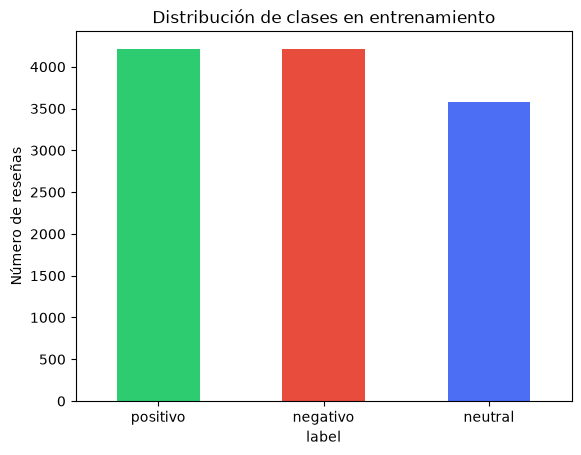

In [35]:
# Distribución de la variable objetivo
conteo = train['label'].value_counts()
porcentaje = train['label'].value_counts(normalize=True).round(3) * 100
display(pd.DataFrame({'cantidad': conteo, 'porcentaje': porcentaje}))

conteo.plot(kind='bar', color=['#2ECC71', '#E74C3C', '#4C6EF5'])
plt.title('Distribución de clases en entrenamiento')
plt.ylabel('Número de reseñas')
plt.xticks(rotation=0)
plt.show()

Las clases `positivo` y `negativo` representan cada una el 35,1 % de los datos y `neutral` el 29,8 %. El desbalance es leve, por lo que:
- No se aplican técnicas de sobremuestreo como SMOTE: la diferencia entre clases no es suficiente para sesgar al modelo de forma importante.
- Toda partición de los datos se hace de forma estratificada para conservar estas proporciones.
- La exactitud (*accuracy*), métrica de la competencia, es adecuada. Como referencia, un modelo que siempre predice la clase mayoritaria obtendría 35,1 %.

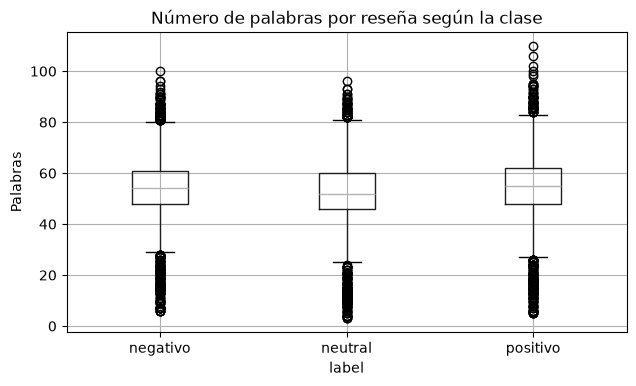

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


In [36]:
# Longitud de las reseñas por clase
train['n_palabras'] = train['text'].str.split().str.len()

train.boxplot(column='n_palabras', by='label', figsize=(7, 4))
plt.suptitle('')
plt.title('Número de palabras por reseña según la clase')
plt.ylabel('Palabras')
plt.show()

train.groupby('label')['n_palabras'].describe().round(1)

Las tres clases tienen una longitud similar (alrededor de 53 palabras en promedio), así que la longitud del texto no aporta información para distinguir el sentimiento.

In [37]:
# Ejemplos de cada clase
for clase in ['negativo', 'neutral', 'positivo']:
    print('=====', clase.upper(), '=====')
    ejemplos = train[train['label'] == clase]['text'].sample(3, random_state=SEED)
    for texto in ejemplos:
        print('-', texto, '\n')

===== NEGATIVO =====
- La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó. 

- Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora. 

- Llevo ya un rato con él, lo compré para usar en la cocina de mi casa y llegó en tres días. En mi opinión el material quedó sólido en general, se siente firme al tocarlo. La duración de la carga terminó siendo mal hecha desde el primer día, y eso que seguí las instrucciones de uso. 

===== NEUTRAL =====
- Lo pedí un martes por la tarde porque justo andaba cerca de la oficina donde lo iba a usar. Llegó en menos de tres días, o sea que el jueves 

In [38]:
# Proporción de reseñas que contienen al menos una tilde o ñ
print('Entrenamiento:', train['text'].str.contains('[áéíóúñ]').mean().round(3))
print('Evaluación:   ', eval_df['text'].str.contains('[áéíóúñ]').mean().round(3))

Entrenamiento: 0.687
Evaluación:    0.686


**Hallazgos de la exploración**
- La mayoría de reseñas mezcla aspectos positivos y negativos. Por ejemplo, *"el soporte técnico me resultó incumplidor (...) Al final de cuentas, la nitidez de la imagen se mantuvo decente"* está etiquetada como `positivo`.
- La opinión que define la clase suele estar al **final de la reseña** o después de **conectores contrastivos** y de conclusión como *pero*, *sin embargo*, *al final de cuentas* o *en pocas palabras*.
- En cambio, los comentarios introducidos con *además* o *de paso* suelen ser secundarios: hay reseñas `positivo` que terminan con una queja menor de este tipo.
- Las reseñas `neutral` describen la compra (envío, color, uso) sin emitir una opinión.
- Cerca del 31 % de las reseñas está escrito sin tildes ni ñ (*"llego"*, *"mananas"*), en la misma proporción en entrenamiento y en evaluación.

Estos hallazgos orientan el preprocesamiento (sección 2) y la construcción de características (sección 4).

## 2. Preprocesamiento del texto
Se define una función de limpieza con los pasos clásicos de preparación de texto. Los pasos de eliminación de stop words y stemming quedan como opciones (`True`/`False`) para medir su efecto antes de decidir si se usan.

| Paso | Qué hace |
|---|---|
| Minúsculas | *"Excelente"* y *"excelente"* pasan a ser el mismo término |
| Quitar tildes y ñ | *"llegó"* y *"llego"* pasan a ser el mismo término, porque el 31 % de las reseñas se escribió sin tildes |
| Quitar signos y números | Elimina caracteres que no aportan al sentimiento. Se conserva el punto porque marca el final de cada oración |
| Stop words (opcional) | Elimina palabras muy frecuentes como *el*, *de*, *que* |
| Stemming (opcional) | Reduce cada palabra a su raíz: *decepcionante* → *decepcion* |

In [39]:
TILDES = {'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u', 'ü': 'u', 'ñ': 'n'}

def quitar_tildes(texto):
    for letra, reemplazo in TILDES.items():
        texto = texto.replace(letra, reemplazo)
    return texto

stop_es = {quitar_tildes(p) for p in stopwords.words('spanish')}
stemmer = SnowballStemmer('spanish')

def limpiar_texto(texto, quitar_stopwords=False, aplicar_stemming=False):
    # 1. Normalización
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s.]', ' ', texto)   # quita signos, excepto el punto
    texto = re.sub(r'\d+', ' ', texto)          # quita números
    texto = re.sub(r'\s+', ' ', texto).strip()  # une espacios repetidos
    # 2. Tokenización
    tokens = texto.split()
    # 3. Stop words
    if quitar_stopwords:
        tokens = [t for t in tokens if t.strip('.') not in stop_es]
    # 4. Stemming
    if aplicar_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

ejemplo = train['text'][1]
print('ORIGINAL:  ', ejemplo)
print('LIMPIO:    ', limpiar_texto(ejemplo))
print('SIN STOP:  ', limpiar_texto(ejemplo, quitar_stopwords=True))
print('STEMMING:  ', limpiar_texto(ejemplo, aplicar_stemming=True))

ORIGINAL:   Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban harto en contestar. Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.
LIMPIO:     se lo compre a un familiar despues de pensarla varias semanas llego en unos cuatro dias a mi casa. la verdad sea dicha el soporte tecnico me resulto incumplidor para lo que necesitaba tardaban harto en contestar. al final de cuentas la nitidez de la imagen se mantuvo decente en el uso diario.
SIN STOP:   compre familiar despues pensarla varias semanas llego cuatro dias casa. verdad dicha soporte tecnico resulto incumplidor necesitaba tardaban harto contestar. final cuentas nitidez imagen mantuvo decente uso diario.
STEMMING:   se lo compr a un famili despu de pens vari seman lleg en unos cuatr dias a mi casa. la verd sea dich el soport tecnic me result incumplidor par l

In [40]:
# Stop words de la lista en español que cambian el sentido de una reseña
palabras_clave = ['no', 'pero', 'muy', 'sin', 'nada', 'mas', 'poco', 'ni']
print([p for p in palabras_clave if p in stop_es])

['no', 'pero', 'muy', 'sin', 'nada', 'mas', 'poco', 'ni']


La lista de stop words en español incluye *no*, *pero*, *muy*, *sin* y *nada*. Al eliminarlas, *"la cámara **no** es buena"* queda igual a *"la cámara es buena"*. Para comprobar con datos si conviene eliminarlas, se comparan las cuatro versiones de limpieza usando el mismo modelo de referencia (TF-IDF + regresión logística) y validación cruzada estratificada de 5 particiones. Así, la única diferencia entre filas es el preprocesamiento.

In [41]:
versiones = {
    'Texto original':            train['text'],
    'Limpieza básica':           train['text'].apply(limpiar_texto),
    'Limpieza + sin stop words': train['text'].apply(limpiar_texto, quitar_stopwords=True),
    'Limpieza + stemming':       train['text'].apply(limpiar_texto, aplicar_stemming=True),
}

modelo_referencia = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('modelo', LogisticRegression(max_iter=2000))
])
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

filas = []
for nombre, textos in versiones.items():
    puntajes = cross_val_score(modelo_referencia, textos, train['label'], cv=kfold, scoring='accuracy')
    vocabulario = len(CountVectorizer().fit(textos).vocabulary_)
    filas.append({'versión': nombre,
                  'palabras distintas': vocabulario,
                  'accuracy media': round(puntajes.mean(), 4),
                  'desviación estándar': round(puntajes.std(), 4)})

pd.DataFrame(filas)

,versión,palabras distintas,accuracy media,desviación estándar
0,Texto original,6035,0.7249,0.0033
1,Limpieza básica,5436,0.7273,0.0037
2,Limpieza + sin stop words,5286,0.7224,0.0058
3,Limpieza + stemming,5028,0.7278,0.0075


**Decisión:** se usa la **limpieza básica**, sin eliminar stop words y sin stemming.
- La limpieza básica mejora la exactitud frente al texto original (0,7249 → 0,7273) y reduce el vocabulario de 6.035 a 5.436 palabras distintas, porque une variantes de una misma palabra.
- Eliminar stop words obtiene la menor exactitud (0,7224): confirma que palabras como *no* o *pero* son necesarias para detectar el sentimiento.
- El stemming obtiene 0,7279, una diferencia de 0,0006 frente a la limpieza básica. Esa diferencia es mucho menor que la desviación estándar entre particiones (≈0,007), así que no es una mejora real. Se prefiere la opción más simple, que además conserva palabras completas y legibles.

La columna `texto_limpio` se crea con esta limpieza y es la que reciben todos los modelos.

In [42]:
train['texto_limpio'] = train['text'].apply(limpiar_texto)
eval_df['texto_limpio'] = eval_df['text'].apply(limpiar_texto)
train[['text', 'texto_limpio']].head(3)

,text,texto_limpio
0,Lo pedí un martes por la noche y me llegó al d...,lo pedi un martes por la noche y me llego al d...
1,Se lo compré a un familiar después de pensarla...,se lo compre a un familiar despues de pensarla...
2,Lo pedí a mediados de mes y me llegó en tres d...,lo pedi a mediados de mes y me llego en tres d...


### 2.1 Segmentación por oraciones y conectores de discurso

La exploración mostró que el sentimiento global no depende de *cuántas* palabras positivas o negativas aparecen, sino de **dónde** aparecen. El enunciado del proyecto lo plantea en los mismos términos: el sentimiento *"depende del orden, de la negación y de los conectores contrastivos"*.

Se distinguen dos familias de conectores, con papeles opuestos:

| Familia | Conectores | Papel esperado |
|---|---|---|
| **Contrastivos** | *pero*, *sin embargo*, *aun así*, *con todo*, *eso sí*, *al final*, *al final de cuentas*, *a fin de cuentas*, *en pocas palabras*, *en resumen*, *aunque* | Introducen la opinión que **domina** el sentimiento global |
| **Aditivos** | *además*, *de paso*, *por cierto*, *por otro lado* | Introducen un comentario **secundario** |

Con esas listas se definen cuatro formas de mirar una misma reseña:

| Vista | Qué conserva |
|---|---|
| `todo` | La reseña completa, igual que en los envíos 1 a 3 |
| `ult` | Únicamente la última oración |
| `cola` | Lo que viene después del último conector contrastivo; si no hay ninguno, la última oración |
| `sin_adit` | La reseña sin las cláusulas que introduce un conector aditivo |

La separación en oraciones se hace por el punto, que `limpiar_texto` conservó justamente para esto. Es una aproximación: fallaría con abreviaturas, aunque `limpiar_texto` ya eliminó los números, que son su causa más frecuente.

In [43]:
CONTRASTIVOS = ['pero', 'sin embargo', 'aun asi', 'con todo', 'eso si',
                'al final de cuentas', 'a fin de cuentas', 'al final',
                'en pocas palabras', 'en resumen', 'aunque']
ADITIVOS = ['ademas', 'de paso', 'por cierto', 'por otro lado']

def _expresion(conectores):
    """Busca cada conector como palabra completa, no dentro de otra palabra.
    Los ordena de mayor a menor longitud para que 'al final de cuentas'
    se detecte antes que 'al final'."""
    alternativas = '|'.join(re.escape(c) for c in sorted(conectores, key=len, reverse=True))
    return re.compile(r'(?:(?<=^)|(?<=\s))(' + alternativas + r')(?=\s|$)')

RE_CONTRASTIVOS = _expresion(CONTRASTIVOS)
RE_ADITIVOS = _expresion(ADITIVOS)

def oraciones(texto):
    partes = [o.strip() for o in texto.split('.') if o.strip()]
    return partes if partes else [texto]

def ultima_oracion(texto):
    return oraciones(texto)[-1]

def cola_contrastiva(texto):
    """Texto posterior al ultimo conector contrastivo. Si no hay ninguno,
    devuelve la ultima oracion, que es la opinion mas reciente."""
    marcas = list(RE_CONTRASTIVOS.finditer(texto))
    return texto[marcas[-1].end():].strip() if marcas else ultima_oracion(texto)

def sin_aditivos(texto):
    """Recorta de cada oracion la clausula que introduce un conector aditivo."""
    conservadas = []
    for oracion in oraciones(texto):
        marcas = list(RE_ADITIVOS.finditer(oracion))
        recortada = oracion[:marcas[0].start()].strip() if marcas else oracion
        if recortada:
            conservadas.append(recortada)
    return ' . '.join(conservadas) if conservadas else texto

ejemplo = train['texto_limpio'][2]
print('COMPLETO :', ejemplo)
print('ULTIMA   :', ultima_oracion(ejemplo))
print('COLA     :', cola_contrastiva(ejemplo))
print('SIN ADIT :', sin_aditivos(ejemplo))

COMPLETO : lo pedi a mediados de mes y me llego en tres dias en su caja normal sin nada fuera de lo comun. lo uso en la oficina casi a diario desde entonces. el diseno se sintio durable desde el primer dia. aun asi la relacion calidad precio se ve desagradable con el tiempo.
ULTIMA   : aun asi la relacion calidad precio se ve desagradable con el tiempo
COLA     : la relacion calidad precio se ve desagradable con el tiempo.
SIN ADIT : lo pedi a mediados de mes y me llego en tres dias en su caja normal sin nada fuera de lo comun . lo uso en la oficina casi a diario desde entonces . el diseno se sintio durable desde el primer dia . aun asi la relacion calidad precio se ve desagradable con el tiempo


### 2.2 ¿Qué parte de la reseña contiene el sentimiento?

Para decidir con datos cuáles vistas aportan, se comparan con el **mismo modelo de referencia** del apartado anterior (TF-IDF + regresión logística) y las mismas cinco particiones estratificadas. Así la única diferencia entre filas es qué parte del texto recibe el modelo. Se añaden dos vistas de control (`Primera oración` y `Antes del conector contrastivo`) que no se usarán en los modelos, pero permiten contrastar la hipótesis.

In [44]:
def primera_oracion(texto):
    return oraciones(texto)[0]

def antes_contrastivo(texto):
    marcas = list(RE_CONTRASTIVOS.finditer(texto))
    return texto[:marcas[-1].start()].strip() if marcas else texto

partes_resena = {
    'Texto completo':                   train['texto_limpio'],
    'Primera oracion':                  train['texto_limpio'].apply(primera_oracion),
    'Ultima oracion':                   train['texto_limpio'].apply(ultima_oracion),
    'Antes del conector contrastivo':   train['texto_limpio'].apply(antes_contrastivo),
    'Despues del conector contrastivo': train['texto_limpio'].apply(cola_contrastiva),
    'Sin clausulas aditivas':           train['texto_limpio'].apply(sin_aditivos),
}

filas = []
for nombre, textos in partes_resena.items():
    puntajes = cross_val_score(modelo_referencia, textos, train['label'], cv=kfold, scoring='accuracy')
    filas.append({'vista': nombre,
                  'palabras distintas': len(CountVectorizer().fit(textos).vocabulary_),
                  'accuracy media': round(puntajes.mean(), 4),
                  'desviacion estandar': round(puntajes.std(), 4)})

display(pd.DataFrame(filas))

tiene = lambda expresion: train['texto_limpio'].apply(lambda t: bool(expresion.search(t))).mean()
print('Proporcion de reseñas con conector contrastivo:', round(tiene(RE_CONTRASTIVOS), 3))
print('Proporcion de reseñas con conector aditivo:   ', round(tiene(RE_ADITIVOS), 3))

,vista,palabras distintas,accuracy media,desviacion estandar
0,Texto completo,5436,0.7273,0.0037
1,Primera oracion,2268,0.4976,0.0101
2,Ultima oracion,3058,0.8575,0.0060
3,Antes del conector contrastivo,5112,0.7558,0.0068
4,Despues del conector contrastivo,3178,0.8634,0.0089
5,Sin clausulas aditivas,5319,0.7192,0.0050


Proporcion de reseñas con conector contrastivo: 0.394
Proporcion de reseñas con conector aditivo:    0.199


**Hallazgos**

| Vista | Palabras distintas | Accuracy |
|---|---|---|
| Texto completo | 5.436 | 0,7273 |
| Primera oración | 2.268 | **0,4976** |
| Última oración | 3.058 | **0,8575** |
| Antes del conector contrastivo | 5.112 | 0,7558 |
| Después del conector contrastivo | 3.178 | **0,8634** |
| Sin cláusulas aditivas | 5.319 | 0,7192 |

- La **primera oración** apenas alcanza 0,4976. Las reseñas abren describiendo la compra (cuándo se pidió, cuánto tardó el envío, en qué caja llegó) sin emitir opinión, así que el comienzo del texto casi no informa.
- La **última oración** alcanza 0,8575: más de 13 puntos por encima del texto completo y con **la mitad del vocabulario**. El sentimiento global se concentra al final de la reseña.
- Comparar lo que está **antes** del conector contrastivo (0,7558) con lo que está **después** (0,8634) confirma la hipótesis: el conector señala cuál de las dos opiniones domina. El 39,4 % de las reseñas contiene al menos uno.
- La vista **sin cláusulas aditivas** no mejora por sí sola (0,7192), porque sigue mirando la reseña entera. Su aporte solo puede evaluarse combinada con las demás, lo que se hace en el envío 5. El 19,9 % de las reseñas contiene un conector aditivo.

Ninguna vista reemplaza al texto completo: cada una conserva una porción distinta de la información y descarta el resto. Por eso los envíos 4 y 5 **las combinan** en un mismo modelo con `ColumnTransformer`, en lugar de elegir una sola.

## 3. Partición entrenamiento / validación
El archivo `eval.csv` no tiene etiquetas, por lo que no permite medir el desempeño localmente. Se reserva el 20 % de `train.csv` como conjunto de **validación**, de forma estratificada y con semilla fija para que los resultados sean replicables.

Cada modelo se entrena con el 80 % restante y se mide sobre validación. Esto permite comparar modelos sin depender del puntaje público de Kaggle, que se calcula con solo el 30 % de los datos de evaluación y tiene un número limitado de envíos.

In [45]:
X = train['texto_limpio']
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print('Entrenamiento:', X_train.shape, '| Validación:', X_val.shape)
pd.DataFrame({'entrenamiento': y_train.value_counts(normalize=True).round(3),
              'validación': y_val.value_counts(normalize=True).round(3)})

Entrenamiento: (9600,) | Validación: (2400,)


,entrenamiento,validación
label,,
negativo,0.351,0.351
neutral,0.298,0.298
positivo,0.351,0.351


Las cuatro vistas se construyen una sola vez y se reparten usando **los mismos índices** de la partición anterior. Así los envíos 4 y 5 se evalúan sobre exactamente las mismas reseñas que los envíos 1 a 3 y la comparación entre envíos sigue siendo válida.

In [46]:
def construir_vistas(textos):
    """Las cuatro representaciones de cada reseña que usan los envíos 4 y 5."""
    return pd.DataFrame({'todo':     textos,
                         'ult':      textos.apply(ultima_oracion),
                         'cola':     textos.apply(cola_contrastiva),
                         'sin_adit': textos.apply(sin_aditivos)},
                        index=textos.index)

vistas = construir_vistas(train['texto_limpio'])
vistas_eval = construir_vistas(eval_df['texto_limpio'])

V_train, V_val = vistas.loc[X_train.index], vistas.loc[X_val.index]
datos_vistas = (V_train, V_val, vistas, vistas_eval)

print('Vistas construidas:', list(vistas.columns))
print('Entrenamiento:', V_train.shape, '| Validación:', V_val.shape)
display(vistas.head(3))

Vistas construidas: ['todo', 'ult', 'cola', 'sin_adit']
Entrenamiento: (9600, 4) | Validación: (2400, 4)


,todo,ult,cola,sin_adit
0,lo pedi un martes por la noche y me llego al d...,viene con su cable y el manual en la caja,viene con su cable y el manual en la caja,lo pedi un martes por la noche y me llego al d...
1,se lo compre a un familiar despues de pensarla...,al final de cuentas la nitidez de la imagen se...,la nitidez de la imagen se mantuvo decente en ...,se lo compre a un familiar despues de pensarla...
2,lo pedi a mediados de mes y me llego en tres d...,aun asi la relacion calidad precio se ve desag...,la relacion calidad precio se ve desagradable ...,lo pedi a mediados de mes y me llego en tres d...


Las proporciones de cada clase se mantienen iguales en ambos conjuntos gracias a la estratificación.

### Función de evaluación y generación de envíos
Todos los modelos de la sección 4 se evalúan con la misma función, que:
1. Entrena el modelo con el conjunto de entrenamiento y calcula la exactitud en entrenamiento y en validación.
2. Registra el resultado en la tabla `resultados`, usada en la sección 5 para comparar los modelos.
3. Reentrena el modelo con **todo** `train.csv` y genera el archivo de envío para Kaggle en la carpeta `submissions/`.

Comparar la exactitud de entrenamiento con la de validación permite detectar sobreajuste: una diferencia grande indica que el modelo memoriza los datos de entrenamiento en lugar de generalizar.

In [47]:
resultados = []

def evaluar_y_enviar(nombre, modelo, descripcion, datos=None):
    # Los envíos 1 a 3 reciben una sola columna de texto; los envíos 4 y 5 reciben
    # el DataFrame con las cuatro vistas. El parámetro `datos` permite usar la misma
    # función en ambos casos: si no se pasa nada, se usan los conjuntos de texto plano.
    ent, val, completo, evaluacion = datos if datos is not None else (
        X_train, X_val, X, eval_df['texto_limpio'])

    # 1. Entrenar con el 80 % y medir
    modelo.fit(ent, y_train)
    acc_train = accuracy_score(y_train, modelo.predict(ent))
    acc_val = accuracy_score(y_val, modelo.predict(val))
    print(f'{nombre} | accuracy entrenamiento: {acc_train:.4f} | validación: {acc_val:.4f}')

    # 2. Registrar el resultado
    resultados.append({'envío': nombre, 'cambio': descripcion,
                       'accuracy entrenamiento': round(acc_train, 4),
                       'accuracy validación': round(acc_val, 4)})

    # 3. Reentrenar con todos los datos y generar el archivo para Kaggle
    modelo.fit(completo, y)
    envio = pd.DataFrame({'id': eval_df['id'],
                          'answer': modelo.predict(evaluacion)})
    envio.to_csv(f'submissions/{nombre}.csv', index=False)
    print(f'Archivo generado: submissions/{nombre}.csv ({len(envio)} filas)')
    return modelo

## 4. Modelos

### Envío 1 — Bolsa de palabras + Naive Bayes
Como punto de partida, cada reseña se representa con el número de veces que aparece cada palabra del vocabulario (`CountVectorizer`). Sobre esos conteos se entrena un Naive Bayes multinomial, que estima qué tan probable es cada palabra en cada clase y asigna a la reseña la clase más probable. El suavizado `alpha=1.0` evita probabilidades de cero para palabras que no aparecen en alguna clase.

In [48]:
from sklearn.naive_bayes import MultinomialNB

modelo_envio1 = Pipeline([
    ('conteos', CountVectorizer()),
    ('modelo', MultinomialNB(alpha=1.0))
])

puntajes = cross_val_score(modelo_envio1, X_train, y_train, cv=kfold, scoring='accuracy')
print(f'Accuracy en validación cruzada: {puntajes.mean():.4f} (desviación {puntajes.std():.4f})')

modelo_envio1 = evaluar_y_enviar('envio1', modelo_envio1, 'Bolsa de palabras + Naive Bayes')

Accuracy en validación cruzada: 0.7049 (desviación 0.0137)
envio1 | accuracy entrenamiento: 0.8199 | validación: 0.7108
Archivo generado: submissions/envio1.csv (3000 filas)


El modelo acierta el 71 % de las reseñas de validación, muy por encima del 35,1 % de predecir siempre la clase mayoritaria. En entrenamiento llega al 82 %, una diferencia de 11 puntos que indica algo de sobreajuste. Su principal limitación es que los conteos no tienen en cuenta el orden de las palabras ni en qué parte de la reseña aparece cada opinión.

### Envío 2 — TF-IDF + Regresión logística
Se reemplazan los conteos por TF-IDF, que le da menos peso a las palabras presentes en casi todas las reseñas (*llego*, *caja*, *dias*) y más a las que ayudan a distinguir una clase (*decepciono*, *encanto*). Como clasificador se usa regresión logística, que aprende un peso por palabra para cada clase y predice la clase con mayor probabilidad.

In [49]:
modelo_envio2 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('modelo', LogisticRegression(max_iter=2000))
])

puntajes = cross_val_score(modelo_envio2, X_train, y_train, cv=kfold, scoring='accuracy')
print(f'Accuracy en validación cruzada: {puntajes.mean():.4f} (desviación {puntajes.std():.4f})')

modelo_envio2 = evaluar_y_enviar('envio2', modelo_envio2, 'TF-IDF + Regresión logística')

Accuracy en validación cruzada: 0.7251 (desviación 0.0120)
envio2 | accuracy entrenamiento: 0.8346 | validación: 0.7388
Archivo generado: submissions/envio2.csv (3000 filas)


La exactitud en validación sube a 74 %, cerca de 3 puntos más que el envío 1, y la brecha con entrenamiento baja a 9,6 puntos. Sin embargo, el modelo sigue viendo palabras sueltas: *"bueno, pero malo"* y *"malo, pero bueno"* tienen la misma representación, aunque el sentimiento global sea distinto.

### Envío 3 — TF-IDF con bigramas y búsqueda de hiperparámetros

Se añaden parejas de palabras consecutivas (bigramas) a los unigramas del envío 2, para que expresiones como *no funciona* o *muy malo*, cuyo sentido depende de dos palabras juntas, se representen como un único término. Se exploran además dos variantes vistas en la práctica 3: el umbral `min_df`, que descarta términos presentes en muy pocas reseñas, y la representación **binaria**, que registra presencia o ausencia en lugar de frecuencia.

| Hiperparámetro | Valores probados | Qué controla |
|---|---|---|
| `C` | 0,1 · 0,3 · 1,0 | Fuerza de la regularización: valores bajos simplifican el modelo |
| `min_df` | 1 · 2 | Número mínimo de reseñas en que debe aparecer un término |
| `binary` | True · False | Presencia/ausencia frente a frecuencia |

Las 12 combinaciones se evalúan con `GridSearchCV` sobre las mismas cinco particiones estratificadas que el resto del cuaderno, de modo que el resultado sea comparable con los envíos anteriores.

In [50]:
base_envio3 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('modelo', LogisticRegression(max_iter=2000, random_state=SEED))
])

rejilla_envio3 = {'tfidf__min_df': [1, 2],
                  'tfidf__binary': [True, False],
                  'modelo__C': [0.1, 0.3, 1.0]}

busqueda3 = GridSearchCV(base_envio3, rejilla_envio3, cv=kfold, scoring='accuracy', n_jobs=-1)
busqueda3.fit(X_train, y_train)

print('Mejor combinación:', busqueda3.best_params_)
print(f'Accuracy en validación cruzada: {busqueda3.best_score_:.4f}')

display(pd.DataFrame(busqueda3.cv_results_)[
    ['param_modelo__C', 'param_tfidf__min_df', 'param_tfidf__binary',
     'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).round(4).reset_index(drop=True))

modelo_envio3 = evaluar_y_enviar('envio3', busqueda3.best_estimator_,
                                 'TF-IDF con unigramas y bigramas + búsqueda de hiperparámetros')

Mejor combinación: {'modelo__C': 1.0, 'tfidf__binary': True, 'tfidf__min_df': 2}
Accuracy en validación cruzada: 0.7278


,param_modelo__C,param_tfidf__min_df,param_tfidf__binary,mean_test_score,std_test_score
0,1.0,2,True,0.7278,0.0176
1,1.0,1,True,0.7261,0.0175
2,1.0,2,False,0.7260,0.0169
3,1.0,1,False,0.7248,0.0176
4,0.3,2,True,0.7184,0.0172
5,0.3,1,True,0.7178,0.0179
6,0.3,2,False,0.7148,0.0161
7,0.3,1,False,0.7141,0.0164
8,0.1,2,True,0.7081,0.0172
9,0.1,1,True,0.7074,0.0175


envio3 | accuracy entrenamiento: 0.9208 | validación: 0.7292
Archivo generado: submissions/envio3.csv (3000 filas)


La mejor combinación es `C=1.0`, `min_df=2` y representación binaria, con 0,7278 en validación cruzada. El resultado es prácticamente igual al del envío 2 (0,7251) y la exactitud en validación incluso **baja** (0,7388 → 0,7292), mientras la brecha entre entrenamiento y validación **se duplica** (0,096 → 0,192): los bigramas añaden miles de términos que aparecen en muy pocas reseñas, el modelo los memoriza y eso no le sirve para generalizar.

**Este resultado negativo es informativo.** Agregar parejas de palabras, filtrar términos poco frecuentes y cambiar a representación binaria agota las variantes de la bolsa de palabras sin romper el techo de ≈0,73. Si la limitación estuviera en *qué* palabras se cuentan, alguna de las 12 combinaciones habría ayudado. Como ninguna lo hace, la limitación es otra: **la bolsa de palabras ignora el orden**. Las frases *"bueno, pero malo"* y *"malo, pero bueno"* producen exactamente el mismo vector, aunque su sentimiento global sea opuesto. El envío 4 ataca justamente eso.

### Envío 4 — Texto completo y última oración

El apartado 2.2 mostró que la última oración sola alcanza 0,8575 frente a 0,7273 del texto completo. En lugar de descartar el texto completo, se combinan las dos vistas: cada una recibe su propio `TfidfVectorizer` y `ColumnTransformer` concatena los dos bloques, de modo que **una sola** regresión logística aprenda a la vez los coeficientes de ambos. Es el mismo patrón de la práctica 7, donde `ColumnTransformer` aplicaba transformaciones distintas a columnas distintas del mismo conjunto.

| Bloque | Entrada | Para qué |
|---|---|---|
| `todo` | Reseña completa | Conserva toda la información, como en los envíos 1 a 3 |
| `ult` | Última oración | Repite la parte donde se concentra el sentimiento, dándole más peso |

Se conservan `min_df=2` y la representación binaria elegidos por la búsqueda del envío 3, para que el **único** cambio respecto a ese envío sea la incorporación de la segunda vista y la mejora pueda atribuirse a ella.

In [51]:
modelo_envio4 = Pipeline([
    ('vistas', ColumnTransformer([
        ('todo', TfidfVectorizer(ngram_range=(1, 2), min_df=2, binary=True), 'todo'),
        ('ult',  TfidfVectorizer(ngram_range=(1, 2), min_df=2, binary=True), 'ult'),
    ])),
    ('modelo', LogisticRegression(C=1.0, max_iter=2000, random_state=SEED))
])

puntajes = cross_val_score(modelo_envio4, V_train, y_train, cv=kfold, scoring='accuracy')
print(f'Accuracy en validación cruzada: {puntajes.mean():.4f} (desviación {puntajes.std():.4f})')

modelo_envio4 = evaluar_y_enviar('envio4', modelo_envio4,
                                 'TF-IDF del texto completo y de la última oración',
                                 datos=datos_vistas)

Accuracy en validación cruzada: 0.8723 (desviación 0.0155)
envio4 | accuracy entrenamiento: 0.9697 | validación: 0.8850
Archivo generado: submissions/envio4.csv (3000 filas)


La exactitud en validación pasa de 0,7292 a 0,8850: **15 puntos** con un único cambio en la representación, sin tocar el clasificador ni sus hiperparámetros. Y la brecha entre entrenamiento y validación baja a 0,085, la **más pequeña** de los cuatro envíos, lo que indica que la mejora no viene de memorizar más, sino de mirar el lugar correcto del texto.

Quedan dos casos sin resolver: aquel en que la opinión dominante no está en la última oración sino introducida por un conector contrastivo en medio del texto, y el de las cláusulas aditivas, que aportan opiniones secundarias y por tanto ruido. El envío 5 añade una vista para cada uno.

### Envío 5 — Conectores contrastivos + búsqueda de hiperparámetros

El envío 4 todavía se equivoca cuando la opinión que domina no está en la última oración o cuando aparece una cláusula aditiva. Se añaden las otras dos vistas del apartado 2.1: `cola`, lo que viene después del último conector contrastivo, y `sin_adit`, la reseña sin las cláusulas aditivas.

Además, sobre `ult` y `cola` se agrega un TF-IDF de n-gramas de caracteres (2 a 5 letras). Cerca de un tercio de las reseñas tiene errores de escritura o no tiene tildes (*terimne*, *decepciono*, *erorr*), y los n-gramas de caracteres reconocen esas variantes como parecidas aunque no sean la misma palabra.

Con `GridSearchCV` y las mismas cinco particiones probamos 12 combinaciones: C = 1, 3 y 10, y los n-gramas de caracteres sobre `ult` y sobre `cola` activados o no. La mejor combinación usa C = 3 y los dos bloques de caracteres, con 0,8919 en validación cruzada. Sin ningún bloque de caracteres la mejor opción llega a 0,8879, así que estos bloques aportan cerca de 0,4 puntos.

In [54]:
palabras = lambda: TfidfVectorizer(ngram_range=(1, 2), min_df=2, binary=True)
caracteres = lambda: TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2, sublinear_tf=True)

base_envio5 = Pipeline([
    ('vistas', ColumnTransformer([
        ('todo',     palabras(),   'todo'),
        ('ult',      palabras(),   'ult'),
        ('cola',     palabras(),   'cola'),
        ('sin_adit', palabras(),   'sin_adit'),
        ('ult_car',  caracteres(), 'ult'),
        ('cola_car', caracteres(), 'cola'),
    ])),
    ('modelo', LogisticRegression(max_iter=5000, random_state=SEED))
])

rejilla_envio5 = {'vistas__ult_car':  [caracteres(), 'drop'],
                  'vistas__cola_car': [caracteres(), 'drop'],
                  'modelo__C': [1, 3, 10]}

busqueda5 = GridSearchCV(base_envio5, rejilla_envio5, cv=kfold, scoring='accuracy', n_jobs=-1)
busqueda5.fit(V_train, y_train)

desviacion = busqueda5.cv_results_['std_test_score'][busqueda5.best_index_]
print(f'Accuracy en validación cruzada: {busqueda5.best_score_:.4f} (desviación {desviacion:.4f})')

tabla = pd.DataFrame(busqueda5.cv_results_)
tabla['n-gramas de caracteres en ult'] = tabla['param_vistas__ult_car'].apply(lambda v: 'no' if v == 'drop' else 'si')
tabla['n-gramas de caracteres en cola'] = tabla['param_vistas__cola_car'].apply(lambda v: 'no' if v == 'drop' else 'si')
display(tabla[['param_modelo__C', 'n-gramas de caracteres en ult', 'n-gramas de caracteres en cola',
               'mean_test_score', 'std_test_score']]
        .sort_values('mean_test_score', ascending=False).round(4).reset_index(drop=True))

modelo_envio5 = evaluar_y_enviar('envio5', busqueda5.best_estimator_,
                                 'Cuatro vistas del texto + n-gramas de caracteres + búsqueda de hiperparámetros',
                                 datos=datos_vistas)

Accuracy en validación cruzada: 0.8919 (desviación 0.0100)


,param_modelo__C,n-gramas de caracteres en ult,n-gramas de caracteres en cola,mean_test_score,std_test_score
0,3,si,si,0.8919,0.0100
1,3,no,si,0.8909,0.0103
2,1,si,si,0.8908,0.0122
3,1,no,si,0.8901,0.0112
4,10,si,si,0.8896,0.0091
5,1,si,no,0.8892,0.0120
6,10,no,si,0.8890,0.0101
7,3,si,no,0.8889,0.0099
8,10,si,no,0.8883,0.0091
9,3,no,no,0.8879,0.0122


envio5 | accuracy entrenamiento: 0.9981 | validación: 0.8975
Archivo generado: submissions/envio5.csv (3000 filas)


La búsqueda confirma que las dos mejoras aportan. Con las cuatro vistas de palabras y sin n-gramas de caracteres, la mejor combinación llega a 0,8879. Al activar los n-gramas de caracteres en `ult` y en `cola` sube a 0,8919, y en todas las combinaciones probadas C = 3 queda igual o por encima de C = 1 y C = 10. Las diferencias entre las 12 combinaciones son pequeñas (de 0,8865 a 0,8919) frente a la desviación entre particiones (≈0,01), así que el modelo no depende mucho de estos hiperparámetros.

Frente al envío 4, la exactitud en validación cruzada sube de 0,8723 a 0,8919 y la de validación de 0,8850 a 0,8975. La mejora viene sobre todo de la vista `cola`, que corrige los casos en que la opinión dominante va después de un conector contrastivo en medio del texto, y de los n-gramas de caracteres, que reconocen palabras mal escritas o sin tildes (*terimne*, *decepciono*).

La brecha entre entrenamiento y validación sube de 0,085 a 0,101. Los n-gramas de caracteres añaden muchos términos y el modelo llega a 0,998 en entrenamiento, así que hay algo más de sobreajuste. Aun así, la exactitud en validación sigue subiendo, entonces las nuevas vistas aportan información real y no solo memorización.

Al revisar los errores encontramos un límite que ningún modelo puede superar. Cerca del 12 % de las reseñas tiene dos opiniones opuestas y cierra con una frase ambivalente, como *"para gustos, colores"*, *"ni fu ni fa"* o *"cada quien que juzgue"*. En esas reseñas la etiqueta es `positivo` en la mitad de los casos y `negativo` en la otra mitad, sin ningún patrón en el texto ni en el orden de las opiniones.

### Envío 6 — Última oración con opinión

Muchas reseñas no terminan con la opinión sino con una frase de relleno ("Lo dejé guardado en el cajón"), así que la vista `ult` a veces no contiene el sentimiento. Se entrena un clasificador de oraciones que distingue oraciones con opinión de oraciones descriptivas. Para entrenarlo se usan las oraciones de las reseñas `neutral` como ejemplos sin opinión y la `cola` de las reseñas `positivo` y `negativo` como ejemplos con opinión. Con él se construyen tres vistas nuevas: `ult_op` (última oración con opinión), `pen_op` (la opinión anterior) y `ult2` (las dos últimas oraciones). Se agregan además n-gramas de caracteres sobre el texto completo y `class_weight='balanced'` por el leve desbalance de la clase `neutral`.

El clasificador de oraciones va dentro del Pipeline, así que en la validación cruzada se entrena solo con las particiones de entrenamiento.

In [62]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion

def modelo_oraciones():
    return Pipeline([
        ('rep', FeatureUnion([
            ('pal', TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
            ('car', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3, sublinear_tf=True)),
        ])),
        ('modelo', LogisticRegression(C=3, max_iter=3000))
    ])

class VistasDeOpinion(BaseEstimator, TransformerMixin):
    def __init__(self, umbral=0.3):
        self.umbral = umbral

    def fit(self, X, y):
        textos, etiquetas = [], []
        for texto, cola, etiqueta in zip(X['todo'], X['cola'], y):
            partes = oraciones(texto) if etiqueta == 'neutral' else [cola]
            textos += partes
            etiquetas += [etiqueta] * len(partes)
        self.modelo_ = modelo_oraciones().fit(textos, etiquetas)
        return self

    def transform(self, X):
        X = X.copy()
        partes = [oraciones(t) for t in X['todo']]
        col_neutral = list(self.modelo_.classes_).index('neutral')
        p_neutral = self.modelo_.predict_proba([o for p in partes for o in p])[:, col_neutral]
        ult_op, pen_op, ult2 = [], [], []
        i = 0
        for p in partes:
            q = p_neutral[i:i + len(p)]
            i += len(p)
            op = [o for o, pn in zip(p, q) if pn < self.umbral]
            ult_op.append(op[-1] if op else p[-1])
            pen_op.append(op[-2] if len(op) > 1 else '')
            ult2.append(' . '.join(p[-2:]))
        X['ult_op'] = ult_op
        X['pen_op'] = pen_op
        X['ult2'] = ult2
        return X

modelo_envio6 = Pipeline([
    ('opinion', VistasDeOpinion(umbral=0.3)),
    ('vistas', ColumnTransformer([
        ('todo',       palabras(),   'todo'),
        ('ult',        palabras(),   'ult'),
        ('cola',       palabras(),   'cola'),
        ('sin_adit',   palabras(),   'sin_adit'),
        ('ult2',       palabras(),   'ult2'),
        ('ult_op',     palabras(),   'ult_op'),
        ('pen_op',     palabras(),   'pen_op'),
        ('todo_car',   caracteres(), 'todo'),
        ('ult_car',    caracteres(), 'ult'),
        ('cola_car',   caracteres(), 'cola'),
        ('ult2_car',   caracteres(), 'ult2'),
        ('ult_op_car', caracteres(), 'ult_op'),
    ])),
    ('modelo', LogisticRegression(C=3, max_iter=5000, class_weight='balanced'))
])

puntajes = cross_val_score(modelo_envio6, V_train, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)
print(f'Accuracy en validación cruzada: {puntajes.mean():.4f} (desviación {puntajes.std():.4f})')

modelo_envio6 = evaluar_y_enviar('envio6', modelo_envio6,
                                 'Vistas de la última oración con opinión + n-gramas de caracteres + class_weight balanced',
                                 datos=datos_vistas)

Accuracy en validación cruzada: 0.9008 (desviación 0.0066)
envio6 | accuracy entrenamiento: 0.9996 | validación: 0.9021
Archivo generado: submissions/envio6.csv (3000 filas)


La exactitud en validación cruzada sube de 0,8919 a 0,9008 y la de validación de 0,8975 a 0,9021. En Kaggle el envío obtuvo 0,8988, muy cerca de la validación cruzada, lo que indica que el modelo generaliza bien a datos que no vio. La brecha entre entrenamiento y validación queda en 0,098, un poco menor que la del envío 5 (0,101), así que la mejora no viene de memorizar más sino de mirar la oración correcta. La vista `ult` fallaba cuando la reseña cerraba con una frase de relleno como "Lo dejé guardado en el cajón", y `ult_op` recupera la última opinión real aunque no esté al final.

El umbral del clasificador de oraciones sí afecta el resultado. Con 0,5 la validación cruzada da 0,9000, con 0,3 da 0,9008 y con 0,2 baja a 0,8980. Con un umbral muy bajo el modelo descarta como relleno oraciones que sí tienen opinión y `ult_op` termina tomando una oración equivocada.

También probamos variantes que no superaron este resultado: la penúltima oración sola, LinearSVC en lugar de regresión logística y n-gramas de caracteres de 1 a 6 letras. Todas quedaron entre 0,892 y 0,896.

El límite sigue siendo el mismo del envío 5. Cerca del 12 % de las reseñas cierra con una frase ambivalente ("para gustos, colores", "ni fu ni fa") y en ellas ningún modelo supera el 50 %, ni siquiera uno entrenado solo con esas reseñas. Por eso el techo realista de la competencia está alrededor de 0,91 a 0,92.

## 5. Comparación de envíos

## 6. Evaluación del mejor modelo

## 7. Modelo final y conclusiones